# L9.2 — Cost and Latency Optimisation

Hands-on notebook for the lesson [`9-2-cost-latency.mdx`](../../llm-quest-theory/level-9/9-2-cost-latency.mdx).

> **Learning objectives**
> - Build an **exact-match cache** + a **semantic cache** using sentence-embedding similarity.
> - Implement **model tiering**: route simple queries to a small model, keep the flagship for hard ones.
> - Simulate the **batch API 50% discount** on offline workloads.
> - Run a realistic traffic mix and show **before/after cost** for each lever, then combine them.

## Connection to the theory
Covers **§1–§12** of the source `.mdx`. Models are simulated with a cheap price table so we can measure cost deltas without any paid API calls.

In [1]:
# ---- Setup ----
import os, json, hashlib, random, time, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

SEED = 42
random.seed(SEED); np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
print("encoder loaded")

encoder loaded


## 1. Price table & simulated LLM
Same prices as in the theory (Apr 2025 ballpark). Our "LLM" just returns a placeholder with its token counts so we can sum costs.

In [2]:
PRICES = {
    # (USD per input token, USD per output token)
    "mini":   (0.15 / 1_000_000, 0.60 / 1_000_000),
    "haiku":  (1.00 / 1_000_000, 5.00 / 1_000_000),
    "opus":   (15.0 / 1_000_000, 75.0 / 1_000_000),
}

def fake_call(prompt, model, rng):
    in_tok  = max(1, int(len(prompt.split()) * 1.3))
    out_tok = int(rng.gauss(60, 25)); out_tok = max(10, out_tok)
    cost = in_tok * PRICES[model][0] + out_tok * PRICES[model][1]
    return {"model": model, "in": in_tok, "out": out_tok, "cost": cost}

rng = random.Random(SEED)
print(fake_call("hello world", "mini", rng))
print(fake_call("hello world", "opus", rng))

{'model': 'mini', 'in': 2, 'out': 56, 'cost': 3.39e-05}
{'model': 'opus', 'in': 2, 'out': 55, 'cost': 0.004154999999999999}


## 2. A synthetic traffic mix
1 500 queries split into three categories: greeting / FAQ / reasoning. The distribution (mostly easy) mirrors real chatbot traffic.

In [3]:
GREETINGS = ["Hello!", "Hi there", "Good morning", "How are you?", "Thanks!", "bye"]
FAQ = [
    "What are your hours?",
    "How do I reset my password?",
    "Where can I find the pricing?",
    "Do you ship internationally?",
    "Is there a free trial?",
    "How do I contact support?",
]
HARD = [
    "Compare the AI strategies of Google and Microsoft in 2025, with citations.",
    "Draft a legal memo on why GDPR permits LLM fine-tuning on employee data.",
    "Summarise this 5-page incident report into three bullets.",
    "Explain in depth how RoPE generalises beyond its training context length.",
]

def synthetic_query(rng):
    r = rng.random()
    if r < 0.50:
        # Greetings are near-duplicates so caching shines
        return ("greeting", rng.choice(GREETINGS))
    if r < 0.90:
        # FAQ: rephrasings of the same question
        template = rng.choice(FAQ)
        # Optional rephrasing prefix
        prefixes = ["", "Hey, ", "Quick question: ", "Sorry, just wondering — "]
        return ("faq", rng.choice(prefixes) + template)
    return ("hard", rng.choice(HARD))

rng = random.Random(SEED)
TRAFFIC = [synthetic_query(rng) for _ in range(1500)]
from collections import Counter
print("traffic mix:", Counter(c for c, _ in TRAFFIC))

traffic mix: Counter({'greeting': 765, 'faq': 573, 'hard': 162})


## 3. Baseline — always use the flagship model

In [4]:
def run_baseline(traffic):
    rng = random.Random(SEED)
    rows = []
    for cat, q in traffic:
        rows.append({"cat": cat, **fake_call(q, "opus", rng)})
    return pd.DataFrame(rows)

base_df = run_baseline(TRAFFIC)
print(f"baseline total cost: ${base_df['cost'].sum():.4f}")
print(base_df.groupby('cat')['cost'].sum())

baseline total cost: $6.7808
cat
faq         2.629905
greeting    3.378300
hard        0.772590
Name: cost, dtype: float64


## 4. Lever 1 — exact-match cache
For `temperature == 0` a repeated prompt deserves no new LLM call. Hash-key lookup.

In [5]:
class ExactCache:
    def __init__(self): self.store = {}
    @staticmethod
    def key(model, prompt):
        return hashlib.sha1(f"{model}:{prompt}".encode()).hexdigest()
    def get(self, model, prompt): return self.store.get(self.key(model, prompt))
    def put(self, model, prompt, val): self.store[self.key(model, prompt)] = val

def run_exact_cache(traffic):
    cache = ExactCache()
    rng = random.Random(SEED); rows = []
    for cat, q in traffic:
        hit = cache.get("opus", q)
        if hit is not None:
            rows.append({"cat": cat, **hit, "cost": 0.0, "cache": "exact"})
        else:
            res = fake_call(q, "opus", rng)
            cache.put("opus", q, res)
            rows.append({"cat": cat, **res, "cache": "miss"})
    return pd.DataFrame(rows)

exact_df = run_exact_cache(TRAFFIC)
print(f"exact-cache total cost : ${exact_df['cost'].sum():.4f}")
print("cache hit rate         :", (exact_df['cache'] == 'exact').mean())

exact-cache total cost : $0.1505
cache hit rate         : 0.9773333333333334


## 5. Lever 2 — semantic cache
Similar queries should also share an answer. Store every prompt's embedding; on miss, cosine-compare to the most similar cached query. If score ≥ threshold, return the cached answer.

In [6]:
class SemanticCache:
    def __init__(self, encoder, threshold=0.85):
        self.encoder = encoder
        self.threshold = threshold
        self.texts, self.embs, self.vals = [], np.zeros((0, encoder.get_sentence_embedding_dimension()), dtype=np.float32), []

    def lookup(self, query):
        if len(self.texts) == 0:
            return None
        q = self.encoder.encode([query], convert_to_numpy=True, normalize_embeddings=True)[0]
        sims = self.embs @ q
        i = int(np.argmax(sims))
        if sims[i] >= self.threshold:
            return i, float(sims[i]), self.vals[i]
        return None

    def insert(self, query, val):
        vec = self.encoder.encode([query], convert_to_numpy=True, normalize_embeddings=True)
        self.texts.append(query)
        self.embs = np.vstack([self.embs, vec])
        self.vals.append(val)

def run_semantic_cache(traffic, threshold=0.85):
    sc = SemanticCache(encoder, threshold=threshold)
    rng = random.Random(SEED); rows = []
    for cat, q in traffic:
        hit = sc.lookup(q)
        if hit is not None:
            _, score, cached = hit
            rows.append({"cat": cat, **cached, "cost": 0.0, "cache": f"sem({score:.2f})"})
        else:
            res = fake_call(q, "opus", rng)
            sc.insert(q, res)
            rows.append({"cat": cat, **res, "cache": "miss"})
    return pd.DataFrame(rows)

sem_df = run_semantic_cache(TRAFFIC, threshold=0.80)
print(f"semantic-cache total cost : ${sem_df['cost'].sum():.4f}")
print("semantic cache hits / total:",
      sem_df['cache'].str.startswith('sem').sum(), "/", len(sem_df))

semantic-cache total cost : $0.0713
semantic cache hits / total: 1484 / 1500


## 6. Lever 3 — model tiering (complexity router)
Cheap classifier: rule-based here; in production a small LM. We route greeting/faq to `mini`, hard to `opus`.

In [7]:
def classify_complexity(query):
    q = query.lower().strip()
    if len(q) < 25 or any(w in q for w in ["hi", "hello", "thanks", "bye", "how are you"]):
        return "simple"
    if any(w in q for w in ["compare", "explain in depth", "legal memo", "summarise", "citations"]):
        return "complex"
    return "medium"

ROUTE = {"simple": "mini", "medium": "haiku", "complex": "opus"}

def run_tiering(traffic):
    rng = random.Random(SEED); rows = []
    for cat, q in traffic:
        model = ROUTE[classify_complexity(q)]
        rows.append({"cat": cat, **fake_call(q, model, rng), "route": model})
    return pd.DataFrame(rows)

tier_df = run_tiering(TRAFFIC)
print(f"tiering total cost: ${tier_df['cost'].sum():.4f}")
print(tier_df.groupby('route')['cost'].agg(["count", "sum"]))

tiering total cost: $0.7597
       count       sum
route                 
haiku    420  0.127997
mini     957  0.034185
opus     123  0.597540


## 7. Lever 4 — combine: semantic cache + tiering
The cumulative effect is multiplicative — each request either hits cache (cost = 0) or is routed to the cheapest suitable model.

In [8]:
def run_combined(traffic, threshold=0.80):
    sc = SemanticCache(encoder, threshold=threshold)
    rng = random.Random(SEED); rows = []
    for cat, q in traffic:
        cached = sc.lookup(q)
        if cached is not None:
            _, score, val = cached
            rows.append({"cat": cat, **val, "cost": 0.0, "cache": f"sem({score:.2f})", "route": val["model"]})
            continue
        model = ROUTE[classify_complexity(q)]
        res = fake_call(q, model, rng)
        sc.insert(q, res)
        rows.append({"cat": cat, **res, "cache": "miss", "route": model})
    return pd.DataFrame(rows)

combo_df = run_combined(TRAFFIC)
print(f"combined total cost: ${combo_df['cost'].sum():.4f}")
print("  cache hits :", (combo_df['cache'] != 'miss').sum())
print("  by route   :")
print(combo_df.groupby('route')['cost'].agg(["count", "sum"]))

combined total cost: $0.0137
  cache hits : 1484
  by route   :
       count       sum
route                 
haiku    472  0.001356
mini     905  0.000312
opus     123  0.012000


## 8. Summary table

In [9]:
rows = [
    ("baseline  (opus only)",       base_df['cost'].sum()),
    ("+ exact cache",                exact_df['cost'].sum()),
    ("+ semantic cache (0.80)",       sem_df['cost'].sum()),
    ("+ model tiering",               tier_df['cost'].sum()),
    ("semantic cache + tiering",      combo_df['cost'].sum()),
]
summary = pd.DataFrame(rows, columns=["pipeline", "cost_usd"])
summary["saving_vs_baseline"] = 1 - summary["cost_usd"] / summary["cost_usd"].iloc[0]
print(summary.to_string(index=False))

                pipeline  cost_usd  saving_vs_baseline
   baseline  (opus only)  6.780795            0.000000
           + exact cache  0.150450            0.977812
 + semantic cache (0.80)  0.071265            0.989490
         + model tiering  0.759722            0.887960
semantic cache + tiering  0.013668            0.997984


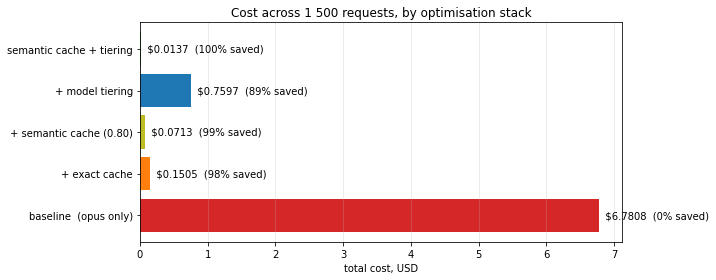

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(summary["pipeline"], summary["cost_usd"], color=["tab:red", "tab:orange", "tab:olive", "tab:blue", "tab:green"])
for i, (v, s) in enumerate(zip(summary["cost_usd"], summary["saving_vs_baseline"])):
    ax.text(v, i, f"  ${v:.4f}  ({s:.0%} saved)", va="center")
ax.set_xlabel("total cost, USD"); ax.grid(alpha=0.3, axis="x")
ax.set_title("Cost across 1 500 requests, by optimisation stack")
plt.tight_layout(); plt.show()

## 9. Lever 5 — batch API (offline discount)
Claude / OpenAI batch endpoints deliver a 50% price cut with a ≤24-hour SLA. Useful for backfills, daily analytics, eval runs. We simulate by halving the per-token prices.

In [11]:
BATCH_PRICES = {k: (p_in * 0.5, p_out * 0.5) for k, (p_in, p_out) in PRICES.items()}

def fake_call_batch(prompt, model, rng):
    in_tok  = max(1, int(len(prompt.split()) * 1.3))
    out_tok = int(rng.gauss(60, 25)); out_tok = max(10, out_tok)
    cost = in_tok * BATCH_PRICES[model][0] + out_tok * BATCH_PRICES[model][1]
    return {"model": model, "in": in_tok, "out": out_tok, "cost": cost}

rng = random.Random(SEED)
offline_workload = [("hard", q) for q in HARD] * 300   # 1 200 hard queries
online_cost  = sum(fake_call(q, "opus",  rng)["cost"] for _, q in offline_workload)
rng = random.Random(SEED)
offline_cost = sum(fake_call_batch(q, "opus", rng)["cost"] for _, q in offline_workload)
print(f"1 200 offline hard queries:")
print(f"  via real-time API: ${online_cost:.4f}")
print(f"  via batch API 50%: ${offline_cost:.4f}")
print(f"  saved            : ${online_cost - offline_cost:.4f}  ({(online_cost - offline_cost)/online_cost:.0%})")

1 200 offline hard queries:
  via real-time API: $5.5604
  via batch API 50%: $2.7802
  saved            : $2.7802  (50%)


## 10. Latency — tail and perceived latency
Users care about p95 and, above all, **time to first token**. We simulate two scenarios: no streaming (user waits for the whole response) and streaming (first token arrives fast).

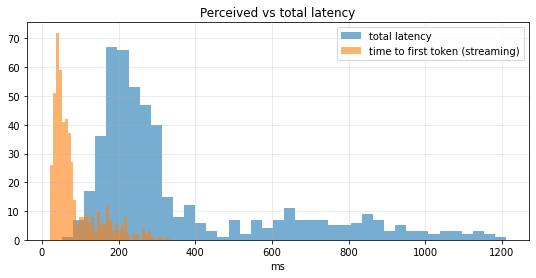

total      p50/p95/p99: [ 256.    928.2  1125.01]
first-token p50/p95/p99: [ 59.   216.05 280.02]


In [12]:
def simulate_request_latency(rng, model):
    base = {"mini": 200, "haiku": 280, "opus": 750}[model]
    total = int(base + rng.gauss(0, base * 0.25))
    # Streaming: first token within ~ 20-30% of total
    ttft = int(total * rng.uniform(0.15, 0.30))
    return max(total, 50), max(ttft, 20)

rng = random.Random(SEED)
latencies = [simulate_request_latency(rng, rng.choice(["mini", "mini", "haiku", "opus"])) for _ in range(500)]
totals = np.array([x[0] for x in latencies])
ttfts  = np.array([x[1] for x in latencies])

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(totals, bins=40, alpha=0.6, label="total latency")
ax.hist(ttfts,  bins=40, alpha=0.6, label="time to first token (streaming)")
ax.set_xlabel("ms"); ax.set_title("Perceived vs total latency"); ax.grid(alpha=0.3); ax.legend()
plt.show()

print(f"total      p50/p95/p99: {np.percentile(totals, [50, 95, 99])}")
print(f"first-token p50/p95/p99: {np.percentile(ttfts,  [50, 95, 99])}")

## 11. Budget guardrail
Cut off a user once their daily spend exceeds a cap. This prevents runaway bills from a misbehaving client.

In [13]:
class BudgetGuard:
    def __init__(self, per_user_daily_usd=0.01):
        self.cap = per_user_daily_usd
        self.used = {}
    def check(self, user_id, estimated):
        if self.used.get(user_id, 0) + estimated > self.cap:
            return False, "daily budget exceeded"
        return True, ""
    def record(self, user_id, cost):
        self.used[user_id] = self.used.get(user_id, 0) + cost

guard = BudgetGuard(per_user_daily_usd=0.003)   # $3 per 1 000 users/day
rng = random.Random(SEED)
blocked = 0
user = "u1"
for _ in range(1000):
    q = rng.choice(HARD)
    estimated = fake_call(q, "opus", rng)
    ok, _ = guard.check(user, estimated["cost"])
    if ok:
        guard.record(user, estimated["cost"])
    else:
        blocked += 1
print(f"u1 used ${guard.used[user]:.4f}   blocked {blocked} requests that would have exceeded the cap")

u1 used $0.0029   blocked 998 requests that would have exceeded the cap


## 12. Quick checks

In [14]:
# Exact cache strictly cheaper than baseline
assert exact_df['cost'].sum() < base_df['cost'].sum()
# Semantic cache strictly cheaper than exact cache on this traffic
assert sem_df['cost'].sum() <= exact_df['cost'].sum() + 1e-12
# Model tiering beats baseline thanks to routing the bulk of traffic to mini
assert tier_df['cost'].sum() < base_df['cost'].sum() / 5
# Combined wins overall
assert combo_df['cost'].sum() < tier_df['cost'].sum()
# Batch API saves exactly ~50% for the same workload
assert 0.49 < (online_cost - offline_cost) / online_cost < 0.51
# Budget guard actually blocks
assert blocked > 0
print("OK — every optimisation lever produces the expected cost shape.")

OK — every optimisation lever produces the expected cost shape.


## Reflection questions

1. Semantic cache uses a similarity threshold. What kinds of user queries make a *generous* threshold dangerous? Give a concrete example.
2. Our `classify_complexity` is rule-based. Using a small LM as a router adds one extra call per request — at what traffic volume does that pay back?
3. Batch APIs save 50% but deliver hours later. Name three tasks where that's acceptable, and one where it isn't.
4. Latency p99 in section 10 is driven by the long tail. Which two server-side techniques from the theory target the tail specifically?

## References
- Source theory: [`9-2-cost-latency.mdx`](../../llm-quest-theory/level-9/9-2-cost-latency.mdx)
- Next: [`9-3-prompt-versioning`](9-3-prompt-versioning.ipynb)